In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/02vvvm705' -- 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences,Wilhelmsha...",https://openalex.org/W4224298083
1,not assigned,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Department of Engineering, Jade University of ...",https://openalex.org/W4224221365
2,not assigned,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences,Department...",https://openalex.org/W4224221365
3,not assigned,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Institute of Hearing Technology and Audiology,...",https://openalex.org/W3134265503
4,not assigned,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade Hochschule Oldenburg, Abteilung Technik u...",https://openalex.org/W4313008767


In [6]:
MAPPING_DICT = {
    'Fachbereich Seefahrt und Logistik': ['maritime', 'marine', 'seefahrt'],
    #'Fachbereich Architektur': [],
    'Fachbereich Bauwesen, Geoinformation, Gesundheitstechnologie': ['geoinformat(ion|ics)', 
                                                                     'audiolog(ie|y)', 'civil', 
                                                                     'hearing technology', 'geoinformati(k|c)',
                                                                     'assistance systems', 'assistive',
                                                                     'acoustics', 'gesundheit',
                                                                     'architecture', 'pflegewissenschaft',
                                                                     'technology and health'],
    'Fachbereich Ingenieurwissenschaften': ['dep(.|t.|ar(t)?ment) of engineering', 'engineering department', 'ingenieurwissenschaften',
                                            'verfahrenstechnik', 'mechatronic systems', 'production and industrial'
                                           ],
    'Fachbereich Management': ['management, information(,| and) technolog(ie|y)'],
    'Fachbereich Wirtschaft': ['wirtschaft und gesellschaft']
}

In [7]:
with open('./mapping_tables_fak/jade.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [8]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [9]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [10]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,None,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences,Wilhelmsha...",https://openalex.org/W4224298083
1,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Department of Engineering, Jade University of ...",https://openalex.org/W4224221365
2,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences,Department...",https://openalex.org/W4224221365
3,"Fachbereich Bauwesen, Geoinformation, Gesundhe...",Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Institute of Hearing Technology and Audiology,...",https://openalex.org/W3134265503
4,"Fachbereich Bauwesen, Geoinformation, Gesundhe...",Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade Hochschule Oldenburg, Abteilung Technik u...",https://openalex.org/W4313008767
...,...,...,...,...
469,"Fachbereich Bauwesen, Geoinformation, Gesundhe...",Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,Institute for Applied Photogrammetry and Geoin...,https://openalex.org/W3096795635
470,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences, Departmen...",https://openalex.org/W3117662728
471,"Fachbereich Bauwesen, Geoinformation, Gesundhe...",Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,Institute for Applied Photogrammetry and Geoin...,https://openalex.org/W3099722383
472,"Fachbereich Bauwesen, Geoinformation, Gesundhe...",Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,Institute for Applied Photogrammetry and Geoin...,https://openalex.org/W3099722383


In [11]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()

array(['Jade University of Applied Sciences,Wilhelmshaven,Germany,26389',
       'Jade University of Applied Sciences, Friedrich-Paffrath-Strae 101, 26389 Wilhelmshaven, Germany',
       'Jade Hochschule, Wilhelmshaven, Deutschland',
       'Jade University of Applied Sciences, Wilhelmshaven/Oldenburg/Elsfleth, Ofener Straße 16/19, 26121 Oldenburg, Germany',
       'Jade University of Applied Sciences, Oldenburg, Germany',
       'Jade University of Applied Science, Wilhelmshaven, Germany, --- Select a Country ---',
       'Jade Hochschule Wilhelmshaven', 'Jade Hochschule Oldenburg',
       'Jade University of Applied Sciences, Friedrich-Paffrath-Str. 101, 26386 Wilhelmshaven, Germany',
       'Jade University of Applied Sciences, Germany',
       'Jade University of applied science, Germany',
       'Jade University of Applied Sciences Friedrich-Paffrath-Straße 101, Wilhelmshaven, Germany',
       'Jade University of Applied Sciences Friedrich-Paffrath-Strae 101, Wilhelmshaven, German

In [12]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,"Fachbereich Bauwesen, Geoinformation, Gesundhe...",191
1,Fachbereich Ingenieurwissenschaften,98
2,Fachbereich Management,13
3,Fachbereich Seefahrt und Logistik,16
4,Fachbereich Wirtschaft,1
5,NaN,155


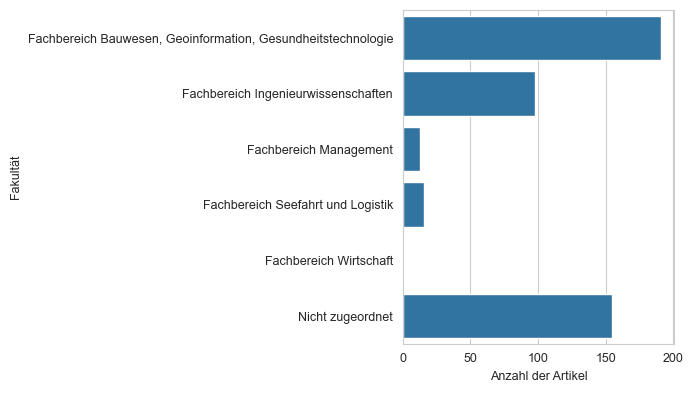

In [13]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [14]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.6729957805907173

In [80]:
MAPPING_DICT_DEPT = {
    'Fachbereich Seefahrt und Logistik': {},
    'Fachbereich Architektur': {
        #'Institut für Architektur und Städtebau Oldenburg (IASO)': [],
        #'Institut für Baumanagement (IBM)': [],
        #'Institut für Intermediale Gestaltung und Darstellung (IGD)': [],
        #'Institut für nachhaltige Architektur und Umweltplanung (INAU)': [],
    },
    'Fachbereich Bauwesen, Geoinformation, Gesundheitstechnologie': {
        'Institut für Hörtechnik und Audiologie': ['hearing technology', 'acoustics', 'audiolog(ie|y)'],
        'Institut für Technische Assistenzsysteme (ITAS)': ['technical (assistance|assistive)', 'assistive technologies'],
        #'Public Health M.Sc.': [],
        #'Studiengang Angewandte Pflegewissenschaft': [],
        'Studiengang Logopädie': ['logopädie'],
        'IAPG Institut für Angewandte Photogrammetrie und Geoinformatik (Standort Oldenburg)': ['photogramm(m)?etr(ie|y)'],
        #'Institut für Mess- und Auswertetechnik (IMA)': [],
        #'Bauchemisches Labor': [],
        #'Baustoffprüflabor - Institut für Materialprüfung': [],
    }
}

In [81]:
with open('./mapping_tables_dept/jade.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [82]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [83]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fachbereich Bauwesen, Geoinformation, Gesundheitstechnologie', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fachbereich Bauwesen, Geoinformation, Gesundheitstechnologie']['raw_affiliation_string'].apply(map_dept, 
                                                                                    faculty='Fachbereich Bauwesen, Geoinformation, Gesundheitstechnologie')

In [84]:
df_with_inst[(df_with_inst['fak_name'] == 'Fachbereich Bauwesen, Geoinformation, Gesundheitstechnologie') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[0:]

array(['Jade Hochschule Oldenburg, Abteilung Technik und Gesundheit für\n                    Menschen, Bremen, Deutschland',
       'Section Technology and Health for Humans, Jade University, 26121 Oldenburg, Germany',
       'Jade Hochschule Oldenburg/Wilhelmshaven/Elsfleth,\n                    Abteilung Technik und Gesundheit für Menschen, Oldenburg,\n                    Deutschland',
       'Jade University of Applied Sciences, Department of Technology and Health for People, Oldenburg, Germany',
       'Section Technology and Health, Jade University of Applied Sciences Oldenburg/Wilhelmshaven/Elsfleth, Ofener Straße 16/19, 26121, Oldenburg, Germany',
       'Department for Civil Engineering Geoinformation and Health Technology, Jade University of Applied Science, 26121 Oldenburg, Germany',
       'Jade University of Applied Sciences,Civil Engineering Geoinformation and Health Technology,Oldenburg,Germany',
       'Civil Engineering Geoinformation and Health Technology, Jade Univers

In [85]:
df_with_inst[df_with_inst['fak_name'] == 'Fachbereich Bauwesen, Geoinformation, Gesundheitstechnologie'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,IAPG Institut für Angewandte Photogrammetrie u...,64
1,Institut für Hörtechnik und Audiologie,66
2,Institut für Technische Assistenzsysteme (ITAS),6
3,Studiengang Logopädie,1
4,NaN,54


In [86]:
df_with_inst[df_with_inst['fak_name'] == 'Fachbereich Bauwesen, Geoinformation, Gesundheitstechnologie']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
3,"Fachbereich Bauwesen, Geoinformation, Gesundhe...",Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Institute of Hearing Technology and Audiology,...",https://openalex.org/W3134265503,Institut für Hörtechnik und Audiologie
4,"Fachbereich Bauwesen, Geoinformation, Gesundhe...",Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade Hochschule Oldenburg, Abteilung Technik u...",https://openalex.org/W4313008767,None
5,"Fachbereich Bauwesen, Geoinformation, Gesundhe...",Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Section Technology and Health for Humans, Jade...",https://openalex.org/W4206237631,None
9,"Fachbereich Bauwesen, Geoinformation, Gesundhe...",Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences, Institute...",https://openalex.org/W4281706237,IAPG Institut für Angewandte Photogrammetrie u...
16,"Fachbereich Bauwesen, Geoinformation, Gesundhe...",Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,Institut f&#x00FC;r H&#x00F6;rtechnik und Audi...,https://openalex.org/W3202836101,Institut für Hörtechnik und Audiologie
...,...,...,...,...,...
467,"Fachbereich Bauwesen, Geoinformation, Gesundhe...",Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Institute of Hearing Technology and Audiology,...",https://openalex.org/W3094040212,Institut für Hörtechnik und Audiologie
468,"Fachbereich Bauwesen, Geoinformation, Gesundhe...",Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences, Institute...",https://openalex.org/W3080295936,IAPG Institut für Angewandte Photogrammetrie u...
469,"Fachbereich Bauwesen, Geoinformation, Gesundhe...",Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,Institute for Applied Photogrammetry and Geoin...,https://openalex.org/W3096795635,IAPG Institut für Angewandte Photogrammetrie u...
471,"Fachbereich Bauwesen, Geoinformation, Gesundhe...",Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,Institute for Applied Photogrammetry and Geoin...,https://openalex.org/W3099722383,IAPG Institut für Angewandte Photogrammetrie u...
